In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

plt.style.use("seaborn-v0_8")

%matplotlib inline

In [2]:
# Imports
from src.config import ModelConfig
from model_run import run_model

In [3]:
def main(max_iter):
    # Configure the run
    DEFAULT_DATA_FILE = os.path.join(os.getcwd(), "scenarios", "Data_Baseline.xlsx")
    cfg = ModelConfig(
        test_mode = True,
        n_test = 168,
        penalty = 10**9,
        demand_target = True,
        sensitivity = False,
        green_electricity = False,
        electricity_mandate = 1.0,
        el_prod_to_grid = 1.0,
        data_file = DEFAULT_DATA_FILE,
        strategic = True,
        co2_label = 'CO2_Liq',
        co2_market_price = 150.0
    )

    scenario_path = Path(cfg.data_file)
    scenario_name = scenario_path.stem.removeprefix("Data_")


    # Run the model and extract results
    final_strategic_model, dual_values, results_summary = run_model(cfg, scenario_name=scenario_name, max_iter=max_iter)

    return results_summary, dual_values, final_strategic_model


In [4]:
# Run model for iter_max = 10 and tol = 1e-2
results_summary, dual_values, final_strategic_model = main(max_iter=10)

Model Run Started
2026-03-10 21:27:00

Building Pyomo model ...

Config values:
test_mode: True
n_test: 168
penalty: 1000000000
demand_target: True
sensitivity: False
green_electricity: False
electricity_mandate: 1.0
el_prod_to_grid: 1.0
data_file: c:\Users\zoewi\OneDrive - Danmarks Tekniske Universitet\GLS-SUS-Optimal\scenarios\Data_Baseline.xlsx
strategic: True
co2_label: CO2_Liq
co2_market_price: 150.0

================= CO2 Market Equilibrium =================

Building and solving initial centralized model...
Centralized baseline solve completed.

Strategic suppliers: ['Digester', 'BiogasUpgrade', 'Boiler', 'CO2Liquefaction']
Initial strategy (total CO2 supply): 242.31

Strategic demanders: ['CO2Compressor', 'CO2Storage', 'MethanolSynthesis']
CO2 initial demand: 242.31, average price: 150.00
Iter 1, Time T0001: excess=-1.63, ratio=-1.13, p_old=150.00, p_delta=-169.83
Iter 1, Time T0002: excess=-1.63, ratio=-1.13, p_old=150.00, p_delta=-169.83
Iter 1, Time T0003: excess=-1.63, rati

In [5]:
# Extract model outputs
print(f"{len(results_summary)} result objects extracted from model run of types {[type(e) for e in results_summary]}")


4 result objects extracted from model run of types [<class 'pandas.DataFrame'>, <class 'pandas.DataFrame'>, <class 'pandas.DataFrame'>, <class 'pandas.DataFrame'>]


In [6]:
results_df = results_summary[2]
print("Results_df")
print(f"{type(results_df)} of {len(results_df)} rows ({results_df.index.name}) and {len(results_df.columns)} columns ({results_df.columns.tolist()[1:]})\n")
print(results_df.head())

Results_df
<class 'pandas.DataFrame'> of 11 rows (Iteration) and 8 columns (['QuantityChange', 'TotalCO2Supply', 'TotalCO2Demand', 'AvgExcessDemand', 'AvgCO2Price', 'BiogasObj', 'MethanolObj'])

           PriceChange  QuantityChange  TotalCO2Supply  TotalCO2Demand  \
Iteration                                                                
0                  NaN             NaN      242.307692      242.307692   
1                 10.0        1.632958      238.946718       16.329583   
2                 10.0        1.632958      239.248262      211.954862   
3                 10.0        1.632958      238.984504      212.607845   
4                 10.0        1.632958      238.551905      212.607845   

           AvgExcessDemand  AvgCO2Price     BiogasObj   MethanolObj  
Iteration                                                            
0                 0.000000   150.000000           NaN           NaN  
1                -1.325102   141.130952  24572.777968 -31739.840545  
2     

In [7]:
best_response_df = results_summary[3]
print("Best_response_df")
print(f"{type(best_response_df)} of {len(best_response_df)} rows ({best_response_df.columns[0]}) and {len(best_response_df.columns)} columns ({best_response_df.columns.tolist()[1:5]}...)\n")
print(best_response_df.head())

Best_response_df
<class 'pandas.DataFrame'> of 168 rows (Time) and 34 columns (['Supply_0', 'Demand_0', 'WTP_0', 'Supply_1']...)

    Time  Supply_0  Demand_0  WTP_0  Supply_1  Demand_1  WTP_1  Supply_2  \
0  T0001  1.632958  1.632958  150.0  1.632958       0.0  140.0  1.632958   
1  T0002  1.632958  1.632958  150.0  1.632958       0.0  140.0  1.632958   
2  T0003  1.632958  1.632958  150.0  1.632958       0.0  140.0  1.632958   
3  T0004  1.632958  1.632958  150.0  1.632958       0.0  140.0  1.632958   
4  T0005  1.632958  1.632958  150.0  1.632958       0.0  140.0  1.632958   

   Demand_2  WTP_2  ...  WTP_7  Supply_8  Demand_8  WTP_8  Supply_9  Demand_9  \
0  1.632958  140.0  ...  140.0  1.632958  1.632958  140.0  1.632958  1.632958   
1  1.632958  140.0  ...  140.0  1.632958  1.632958  140.0  1.632958  1.632958   
2  1.632958  140.0  ...  140.0  1.632958  1.632958  140.0  1.632958  1.632958   
3  1.632958  140.0  ...  140.0  1.632958  1.632958  140.0  1.632958  1.632958   
4  1.632

In [8]:
# Create convergence diagnostics

"""
Main plots:
    - Supply vs demand over iterations
    - Excess demand over iterations
    - CO2 price evolution
    - Price step size

These reveal whether the algorithm: converges, oscillates, diverges, stalls.
"""

'\nMain plots:\n    - Supply vs demand over iterations\n    - Excess demand over iterations\n    - CO2 price evolution\n    - Price step size\n\nThese reveal whether the algorithm: converges, oscillates, diverges, stalls.\n'

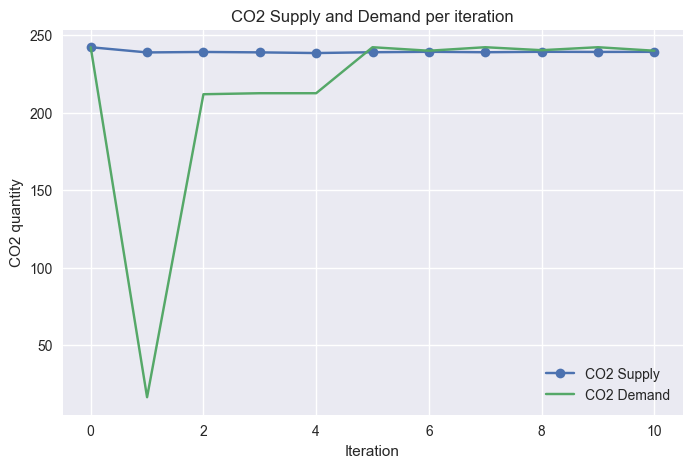

In [9]:
# Plot Supply vs Demand
plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['TotalCO2Supply'], marker='o', label='CO2 Supply')
plt.plot(results_df.index, results_df['TotalCO2Demand'], marker='x', label='CO2 Demand')
plt.xlabel('Iteration')
plt.ylabel('CO2 quantity')
plt.title('CO2 Supply and Demand per iteration')
plt.legend()
plt.show()

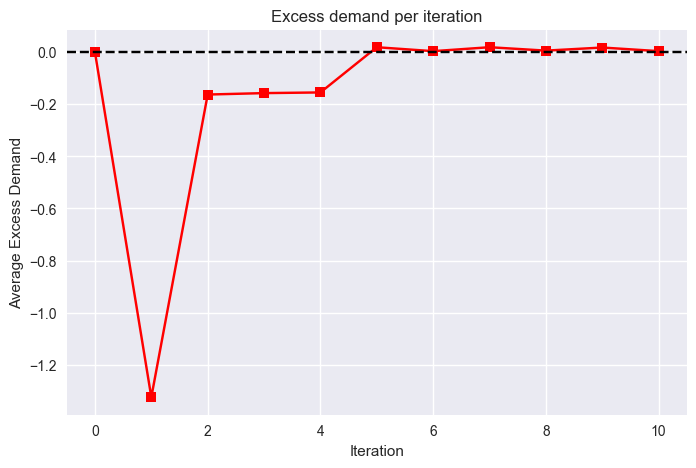

In [10]:
# Plot Excess Demand
plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['AvgExcessDemand'], marker='s', color='red')
plt.xlabel('Iteration')
plt.ylabel('Average Excess Demand')
plt.title('Excess demand per iteration')
plt.axhline(0, color='black', linestyle='--')
plt.show()

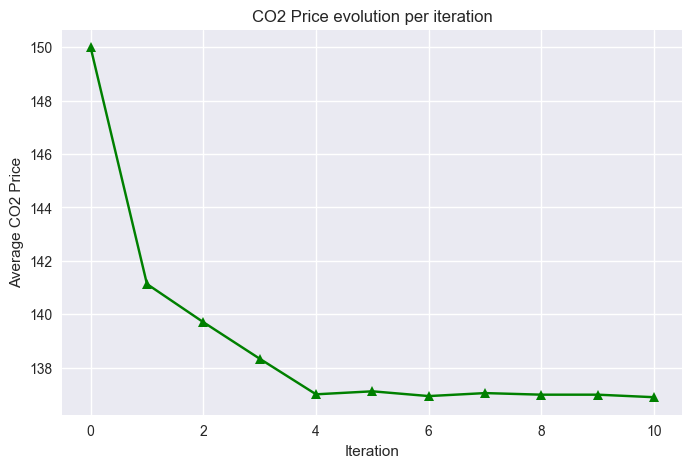

In [11]:
# Plot CO2 Price
plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['AvgCO2Price'], marker='^', color='green')
plt.xlabel('Iteration')
plt.ylabel('Average CO2 Price')
plt.title('CO2 Price evolution per iteration')
plt.show()

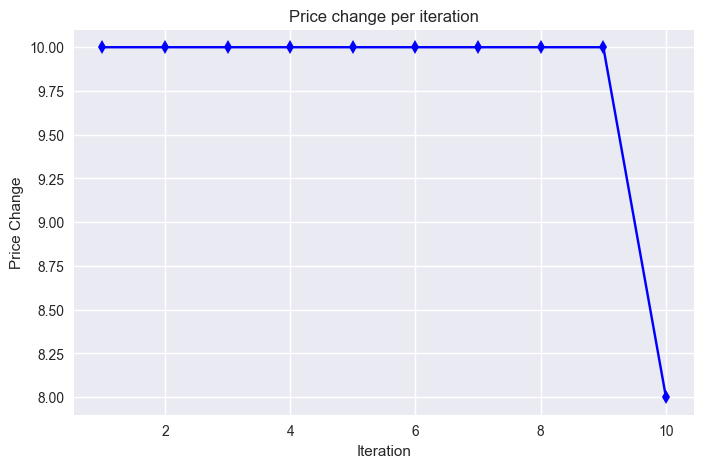

In [12]:
# Plot PriceChange
plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['PriceChange'], marker='d', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Price Change')
plt.title('Price change per iteration')
plt.show()

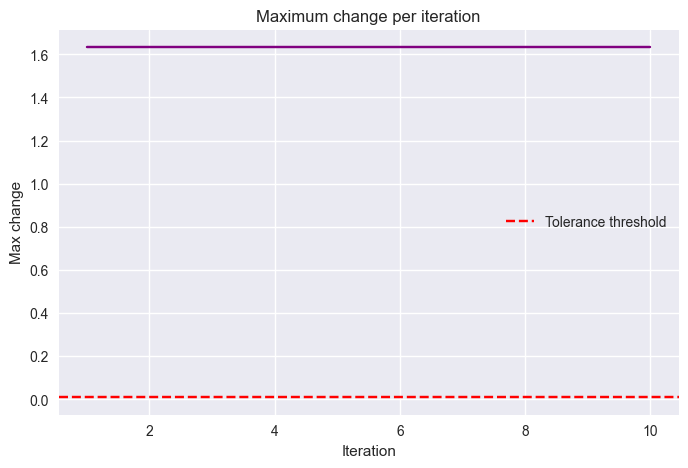

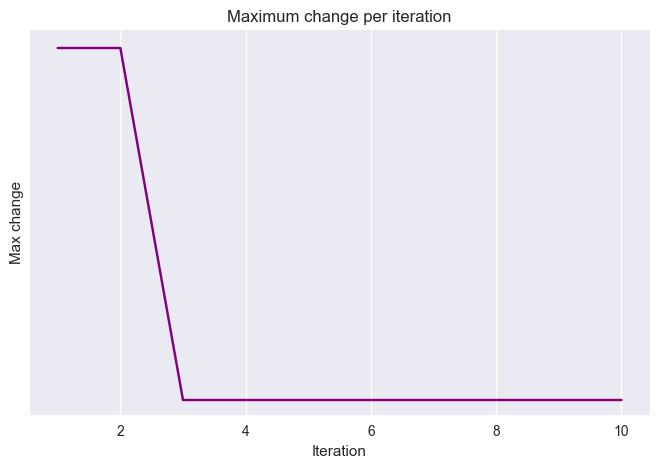

In [13]:
# Plot MaxChange
plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['QuantityChange'], color='purple')
plt.xlabel('Iteration')
plt.ylabel('Max change')
plt.title('Maximum change per iteration')
plt.axhline(1e-2, color='red', linestyle='--', label='Tolerance threshold')
plt.legend()

# Log scale version
plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['QuantityChange'], color='purple')
plt.xlabel('Iteration')
plt.ylabel('Max change')
plt.title('Maximum change per iteration')
plt.yscale('log')  # helps see small changes
plt.show()

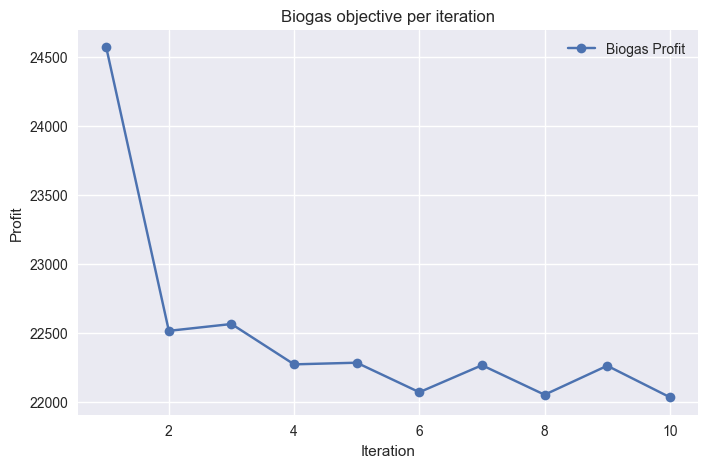

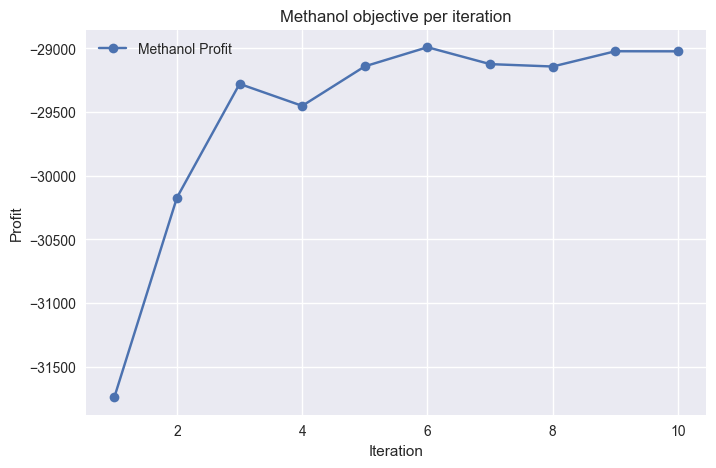

In [14]:
# Actor Objectives
plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['BiogasObj'], label='Biogas Profit', marker='o')
plt.xlabel('Iteration')
plt.ylabel('Profit')
plt.title('Biogas objective per iteration')
plt.legend()

plt.figure(figsize=(8,5))
plt.plot(results_df.index, results_df['MethanolObj'], label='Methanol Profit', marker='o')
plt.xlabel('Iteration')
plt.ylabel('Profit')
plt.title('Methanol objective per iteration')
plt.legend()
plt.show()

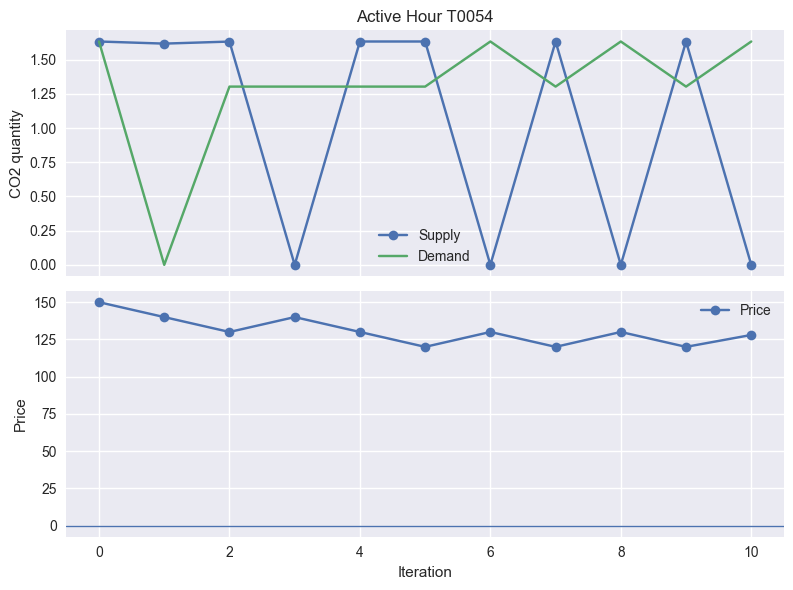

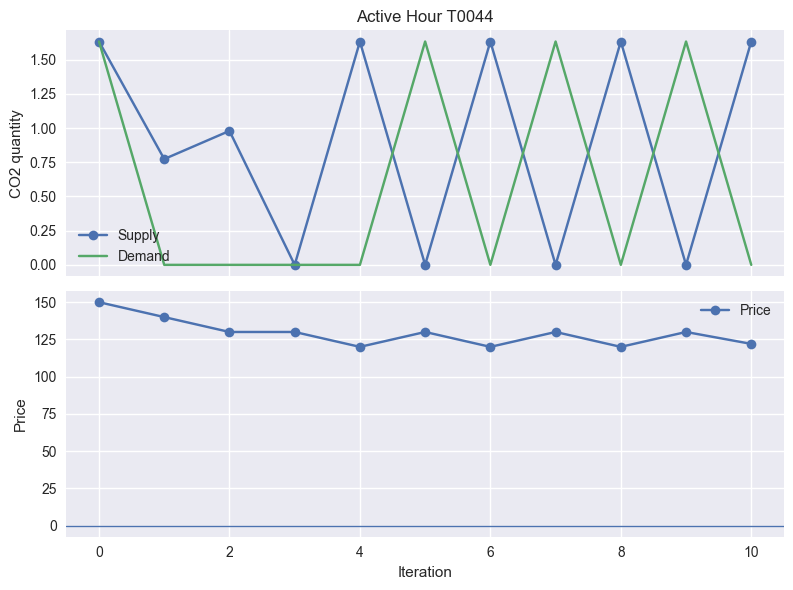

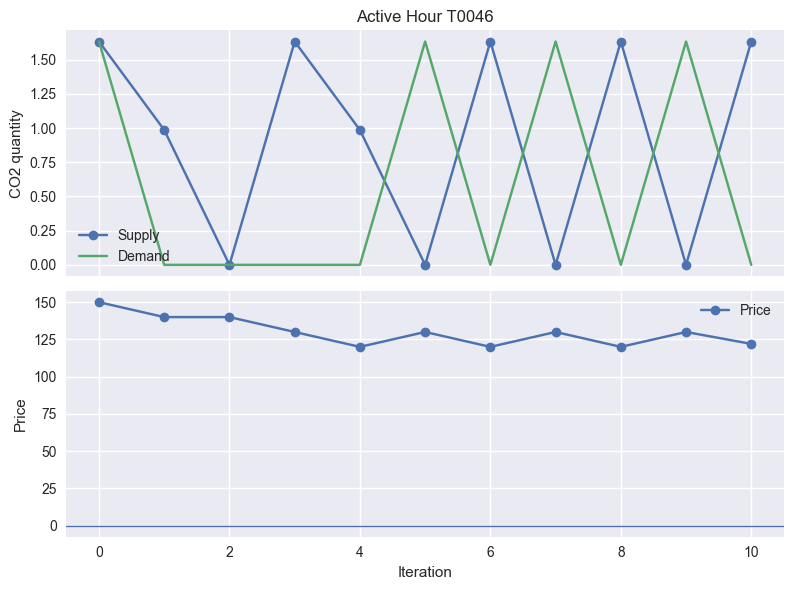

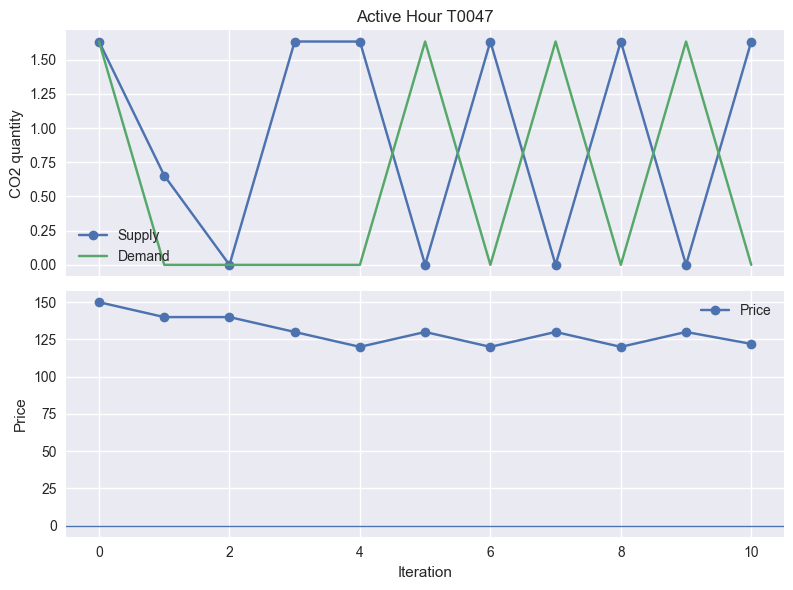

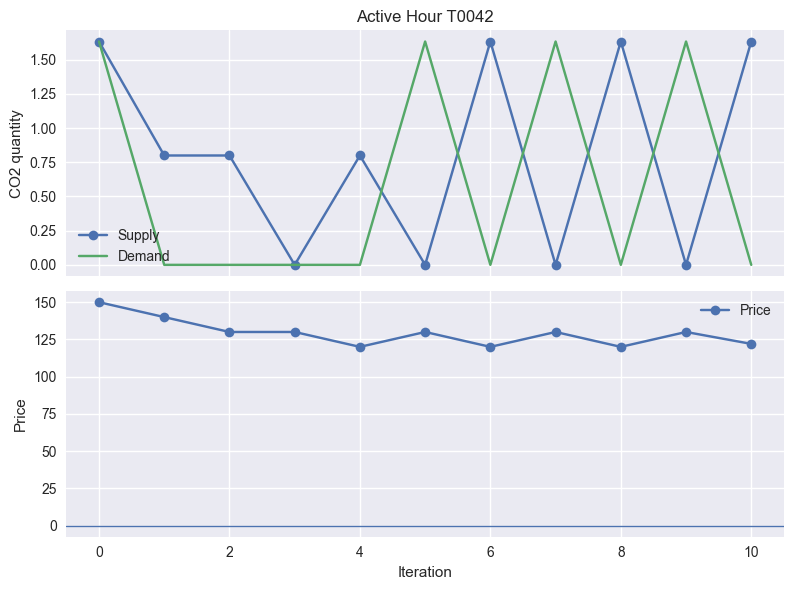

In [15]:
rows = []

for col in best_response_df.columns:
    if col == "Time":
        continue

    var, iteration = col.split("_")
    iteration = int(iteration)

    tmp = best_response_df[["Time", col]].copy()
    tmp["variable"] = var
    tmp["iteration"] = iteration
    tmp.rename(columns={col: "value"}, inplace=True)

    rows.append(tmp)

long_df = pd.concat(rows)

long_df = long_df.pivot_table(
    index=["Time", "iteration"],
    columns="variable",
    values="value"
).reset_index()

long_df = long_df.sort_values(["Time", "iteration"])

long_df["price_change"] = long_df.groupby("Time")["WTP"].diff()

active_hours = (
    long_df.groupby("Time")["price_change"]
    .apply(lambda x: x.abs().sum())
)

active_hours = active_hours[active_hours > 0].index

top_hours = (
    long_df.groupby("Time")["price_change"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(5)
    .index
)

hours_to_plot = top_hours

for t in hours_to_plot:

    subset = long_df[long_df["Time"] == t]

    fig, axes = plt.subplots(2, 1, figsize=(8,6), sharex=True)

    # --- Supply and Demand ---
    axes[0].plot(subset["iteration"], subset["Supply"], marker="o", label="Supply")
    axes[0].plot(subset["iteration"], subset["Demand"], marker="x", label="Demand")
    axes[0].set_ylabel("CO2 quantity")
    axes[0].set_title(f"Active Hour {t}")
    axes[0].legend()
    axes[0].grid(True)

    # --- Price ---
    axes[1].plot(subset["iteration"], subset["WTP"], marker="o", label="Price")
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Price")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

Model Run Started
2026-03-10 21:31:57

Building Pyomo model ...

Config values:
test_mode: True
n_test: 168
penalty: 1000000000
demand_target: True
sensitivity: False
green_electricity: False
electricity_mandate: 1.0
el_prod_to_grid: 1.0
data_file: c:\Users\zoewi\OneDrive - Danmarks Tekniske Universitet\GLS-SUS-Optimal\scenarios\Data_Baseline.xlsx
strategic: True
co2_label: CO2_Liq
co2_market_price: 150.0

================= CO2 Market Equilibrium =================

Building and solving initial centralized model...
Centralized baseline solve completed.

Strategic suppliers: ['Digester', 'BiogasUpgrade', 'Boiler', 'CO2Liquefaction']
Initial strategy (total CO2 supply): 242.31

Strategic demanders: ['CO2Compressor', 'CO2Storage', 'MethanolSynthesis']
CO2 initial demand: 242.31, average price: 150.00
Iter 1, Time T0001: excess=-1.63, ratio=-1.13, p_old=150.00, p_delta=-169.83
Iter 1, Time T0002: excess=-1.63, ratio=-1.13, p_old=150.00, p_delta=-169.83
Iter 1, Time T0003: excess=-1.63, rati

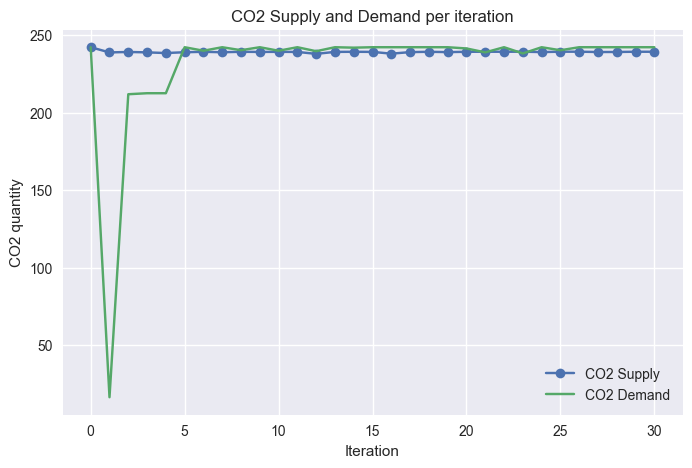

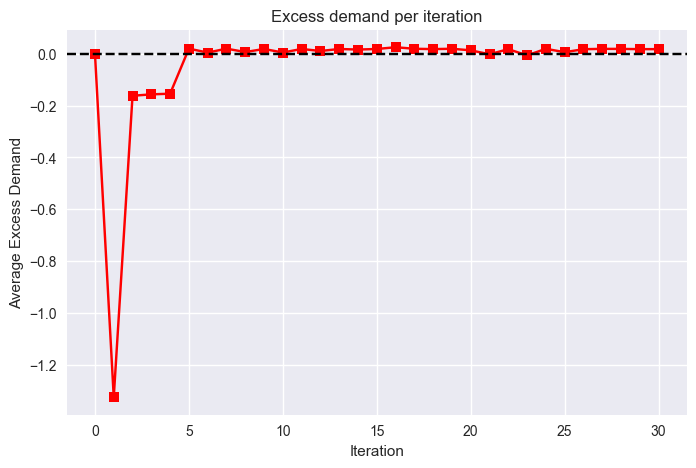

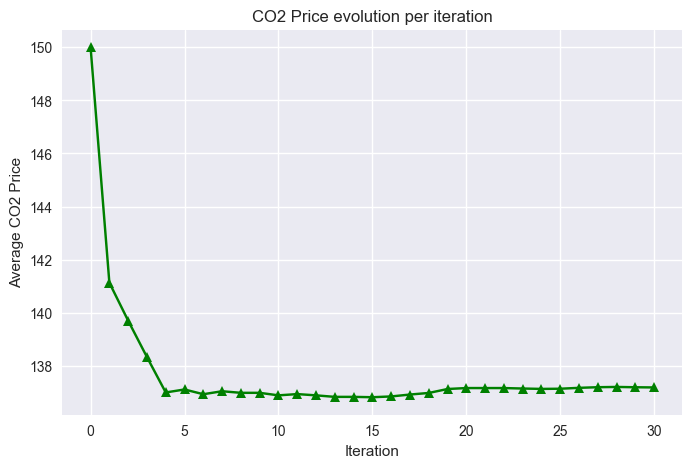

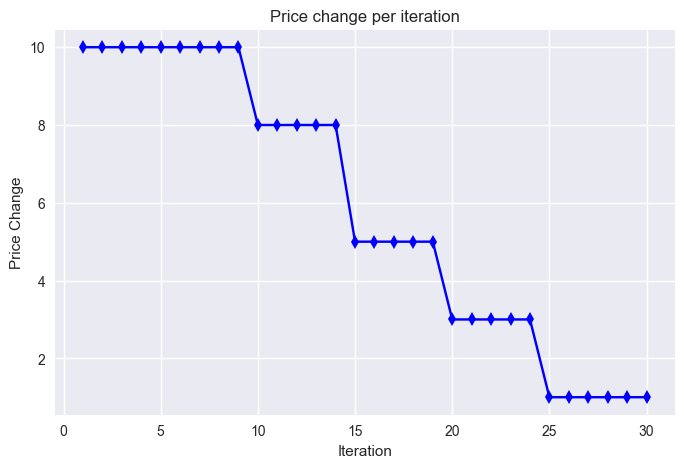

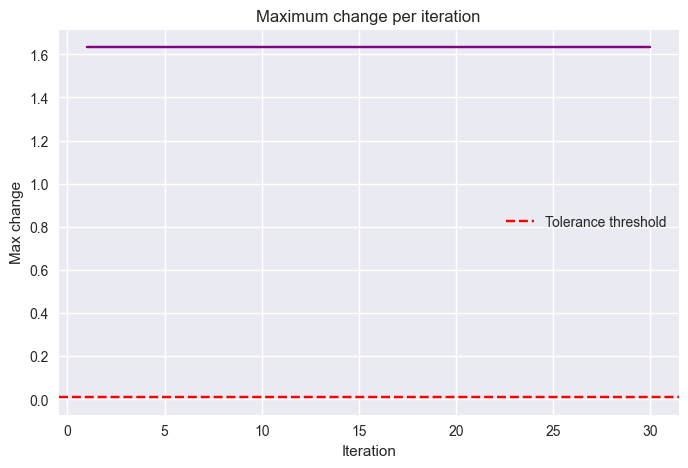

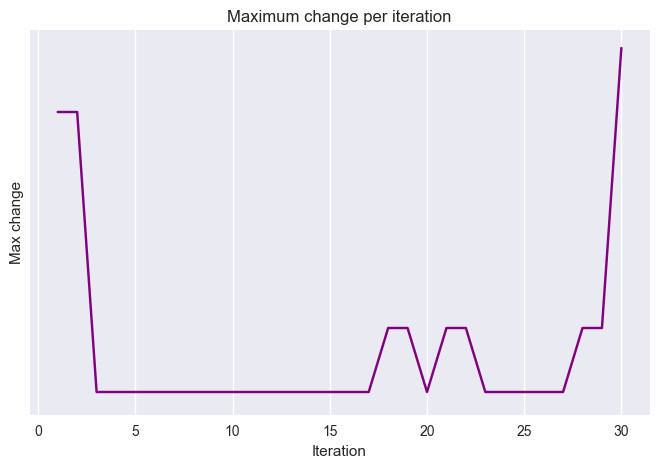

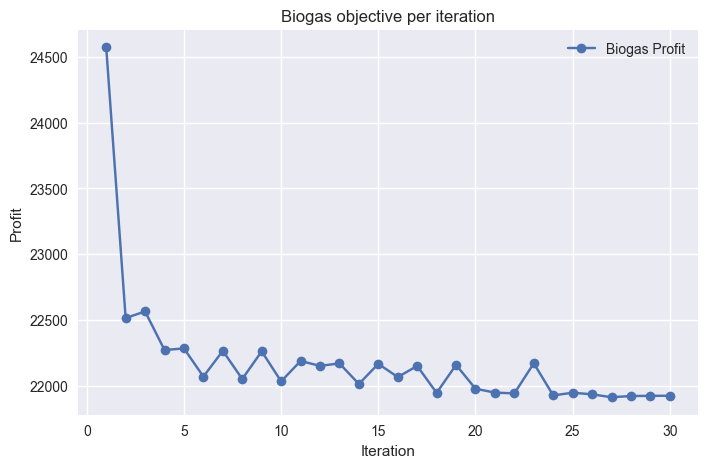

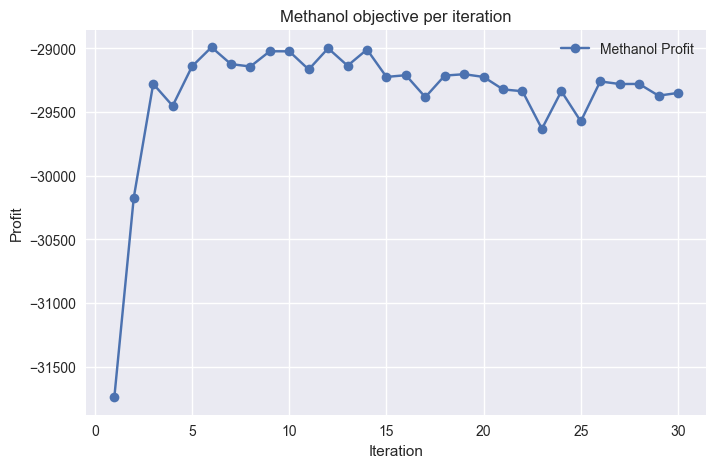

In [16]:
# Run model for iter_max = 30 and tol = 1e-2
results_summary_iter30, dual_values, final_strategic_model = main(max_iter=30)
# Extract model outputs
print(f"{len(results_summary_iter30)} result objects extracted from model run of types {[type(e) for e in results_summary_iter30]}")

results_df_iter30 = results_summary_iter30[2]
print("Results_df")
print(f"{type(results_df_iter30)} of {len(results_df_iter30)} rows ({results_df_iter30.index.name}) and {len(results_df_iter30.columns)} columns ({results_df_iter30.columns.tolist()[1:]})\n")
print(results_df_iter30.head())
best_response_df_iter30 = results_summary_iter30[3]
print("Best_response_df")
print(f"{type(best_response_df_iter30)} of {len(best_response_df_iter30)} rows ({best_response_df_iter30.columns[0]}) and {len(best_response_df_iter30.columns)} columns ({best_response_df_iter30.columns.tolist()[1:5]}...)\n")
print(best_response_df_iter30.head())
# Create convergence diagnostics

"""
Main plots:
    - Supply vs demand over iterations
    - Excess demand over iterations
    - CO2 price evolution
    - Price step size

These reveal whether the algorithm: converges, oscillates, diverges, stalls.
"""
# Plot Supply vs Demand
plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['TotalCO2Supply'], marker='o', label='CO2 Supply')
plt.plot(results_df_iter30.index, results_df_iter30['TotalCO2Demand'], marker='x', label='CO2 Demand')
plt.xlabel('Iteration')
plt.ylabel('CO2 quantity')
plt.title('CO2 Supply and Demand per iteration')
plt.legend()
plt.show()
# Plot Excess Demand
plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['AvgExcessDemand'], marker='s', color='red')
plt.xlabel('Iteration')
plt.ylabel('Average Excess Demand')
plt.title('Excess demand per iteration')
plt.axhline(0, color='black', linestyle='--')
plt.show()
# Plot CO2 Price
plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['AvgCO2Price'], marker='^', color='green')
plt.xlabel('Iteration')
plt.ylabel('Average CO2 Price')
plt.title('CO2 Price evolution per iteration')
plt.show()
# Plot PriceChange
plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['PriceChange'], marker='d', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Price Change')
plt.title('Price change per iteration')
plt.show()
# Plot MaxChange
plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['QuantityChange'], color='purple')
plt.xlabel('Iteration')
plt.ylabel('Max change')
plt.title('Maximum change per iteration')
plt.axhline(1e-2, color='red', linestyle='--', label='Tolerance threshold')
plt.legend()

# Log scale version
plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['QuantityChange'], color='purple')
plt.xlabel('Iteration')
plt.ylabel('Max change')
plt.title('Maximum change per iteration')
plt.yscale('log')  # helps see small changes
plt.show()
# Actor Objectives
plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['BiogasObj'], label='Biogas Profit', marker='o')
plt.xlabel('Iteration')
plt.ylabel('Profit')
plt.title('Biogas objective per iteration')
plt.legend()

plt.figure(figsize=(8,5))
plt.plot(results_df_iter30.index, results_df_iter30['MethanolObj'], label='Methanol Profit', marker='o')
plt.xlabel('Iteration')
plt.ylabel('Profit')
plt.title('Methanol objective per iteration')
plt.legend()
plt.show()

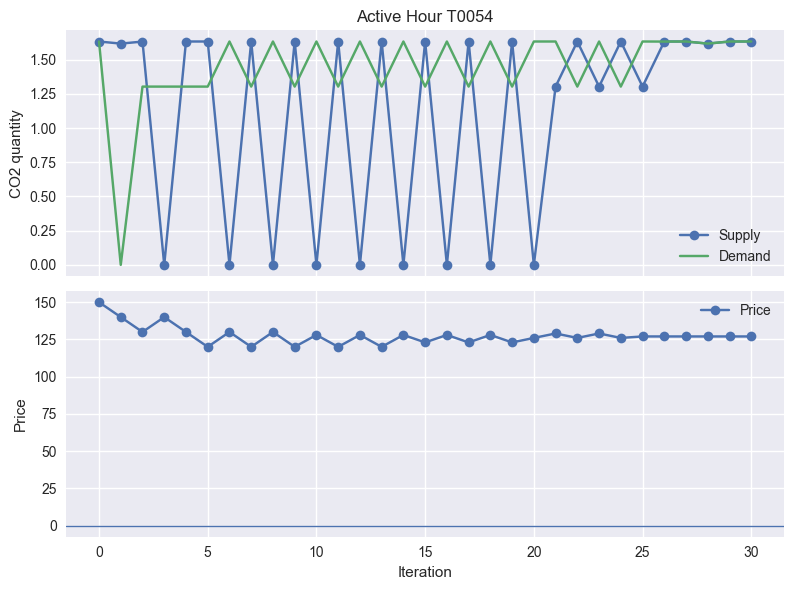

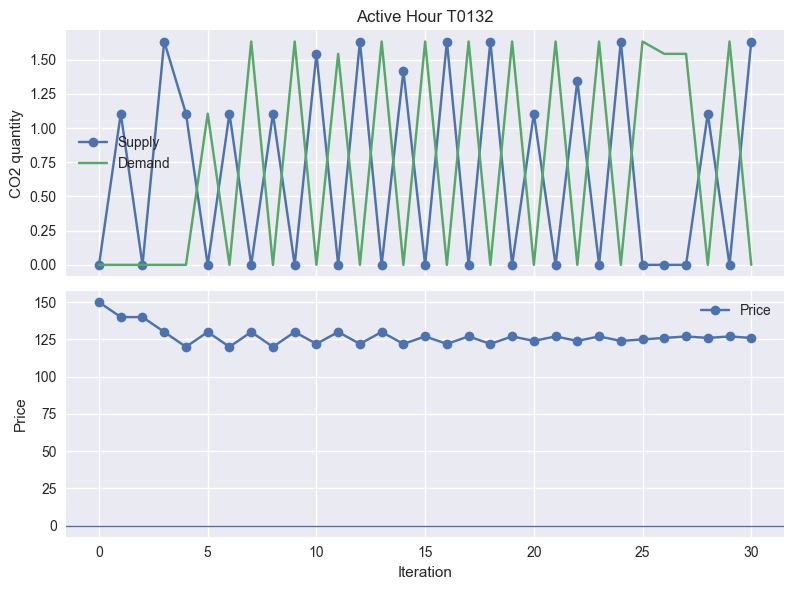

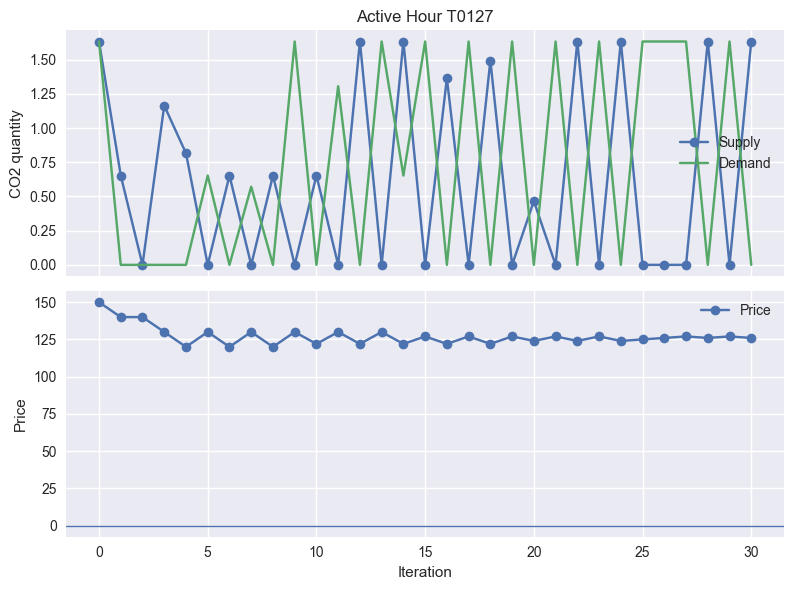

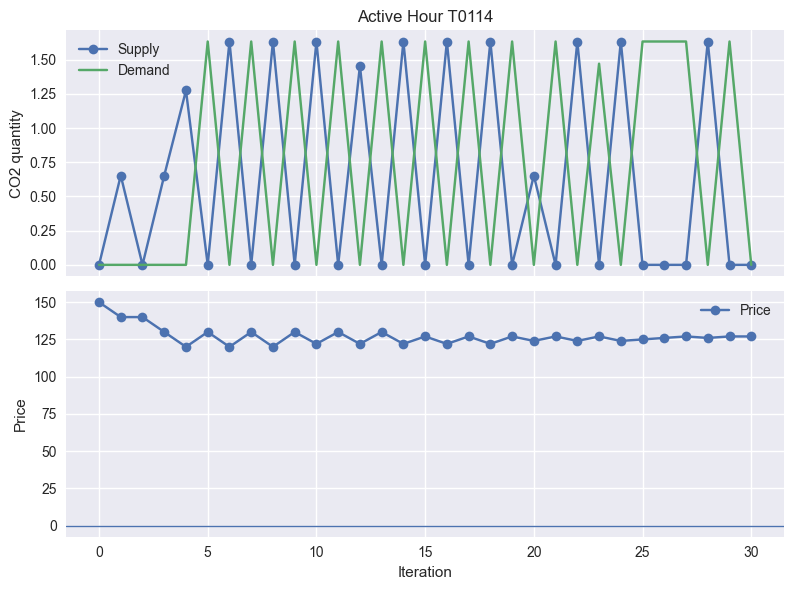

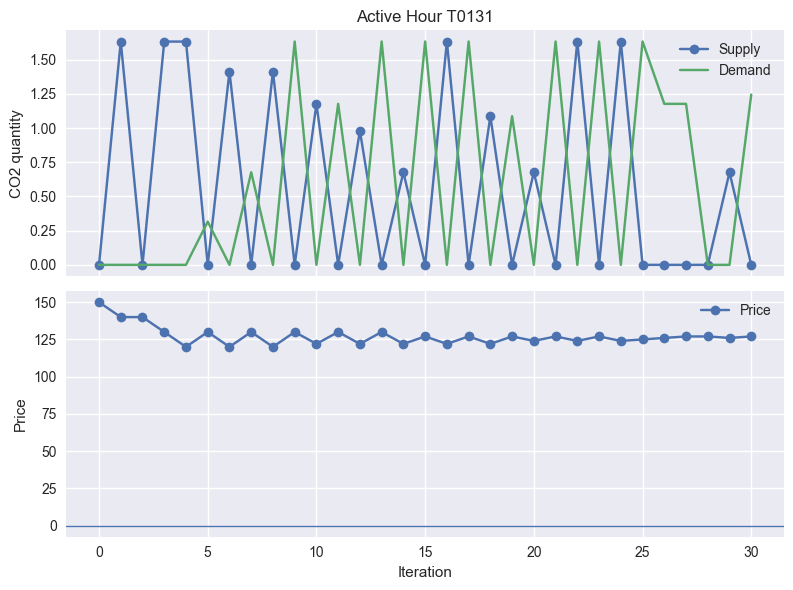

In [17]:
rows = []

for col in best_response_df_iter30.columns:
    if col == "Time":
        continue

    var, iteration = col.split("_")
    iteration = int(iteration)

    tmp = best_response_df_iter30[["Time", col]].copy()
    tmp["variable"] = var
    tmp["iteration"] = iteration
    tmp.rename(columns={col: "value"}, inplace=True)

    rows.append(tmp)

long_df = pd.concat(rows)

long_df = long_df.pivot_table(
    index=["Time", "iteration"],
    columns="variable",
    values="value"
).reset_index()

long_df = long_df.sort_values(["Time", "iteration"])

long_df["price_change"] = long_df.groupby("Time")["WTP"].diff()

active_hours = (
    long_df.groupby("Time")["price_change"]
    .apply(lambda x: x.abs().sum())
)

active_hours = active_hours[active_hours > 0].index

top_hours = (
    long_df.groupby("Time")["price_change"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(5)
    .index
)

hours_to_plot = top_hours

for t in hours_to_plot:

    subset = long_df[long_df["Time"] == t]

    fig, axes = plt.subplots(2, 1, figsize=(8,6), sharex=True)

    # --- Supply and Demand ---
    axes[0].plot(subset["iteration"], subset["Supply"], marker="o", label="Supply")
    axes[0].plot(subset["iteration"], subset["Demand"], marker="x", label="Demand")
    axes[0].set_ylabel("CO2 quantity")
    axes[0].set_title(f"Active Hour {t}")
    axes[0].legend()
    axes[0].grid(True)

    # --- Price ---
    axes[1].plot(subset["iteration"], subset["WTP"], marker="o", label="Price")
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Price")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [18]:
# Tune the price update rule

"""
If convergence is poor you will adjust:
    - alpha (step size)
    - market scale normalization
    - price step limits
"""

'\nIf convergence is poor you will adjust:\n    - alpha (step size)\n    - market scale normalization\n    - price step limits\n'

In [19]:
# Once convergence works, extract final results and analyze firm-level outcomes

"""
Then you can produce the actual research results:
    - equilibrium CO₂ price
    - internal CO₂ flows
    - actor profits
    - comparison with centralized benchmark
    
These will directly answer your research questions.
"""

'\nThen you can produce the actual research results:\n    - equilibrium CO₂ price\n    - internal CO₂ flows\n    - actor profits\n    - comparison with centralized benchmark\n\nThese will directly answer your research questions.\n'